<a href="https://colab.research.google.com/github/EduPekUfpr/PythonProject/blob/main/LDS_RegressaoLinear_Lab_01_GABARITO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style ="text-align:center">
    <img src="https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# SAOP09 - Data Science For Business
## Prof. Eduardo Pécora

## LAB - Regressão Linear — GABARITO

> **Material de uso do professor.** O Lab é um exercício aberto — não há uma única solução correta. Este notebook mostra **um** caminho possível, usando as técnicas ensinadas ao longo do curso (codificação de variáveis categóricas, `drop='first'`, treino/teste, R² e indicadores de erro). Respostas de alunos podem — e devem — variar em escolhas de variáveis, parâmetros e interpretação.

## Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

%matplotlib inline

## Importando os dados

In [2]:
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/Forest_Fires.csv"

df = pd.read_csv(caminho, index_col=0)

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## Entendimento dos dados

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 56.5+ KB


In [4]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [5]:
df.isnull().sum()

,0
X,0
Y,0
month,0
day,0
FFMC,0
DMC,0
DC,0
ISI,0
temp,0
RH,0


## Análise exploratória

### Distribuição da área queimada

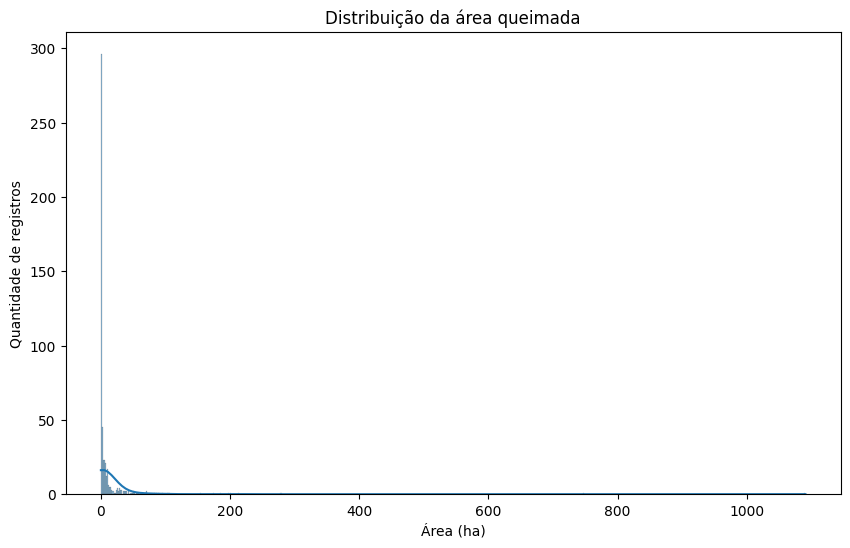

Registros com area == 0: 247 de 517 (47.8%)


In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['area'], kde=True)
plt.title('Distribuição da área queimada')
plt.xlabel('Área (ha)')
plt.ylabel('Quantidade de registros')
plt.show()

print(f"Registros com area == 0: {(df['area']==0).sum()} de {len(df)} ({100*(df['area']==0).mean():.1f}%)")

A variável-alvo é extremamente assimétrica: quase metade dos registros tem área queimada igual a zero, e a grande maioria dos incêndios é pequena — mas alguns poucos incêndios enormes (o maior passa de 1000 ha) puxam a média bem para cima da mediana. Isso é um desafio conhecido deste dataset, e vale ter em mente ao interpretar o desempenho do modelo mais adiante.

### Correlação entre as variáveis numéricas

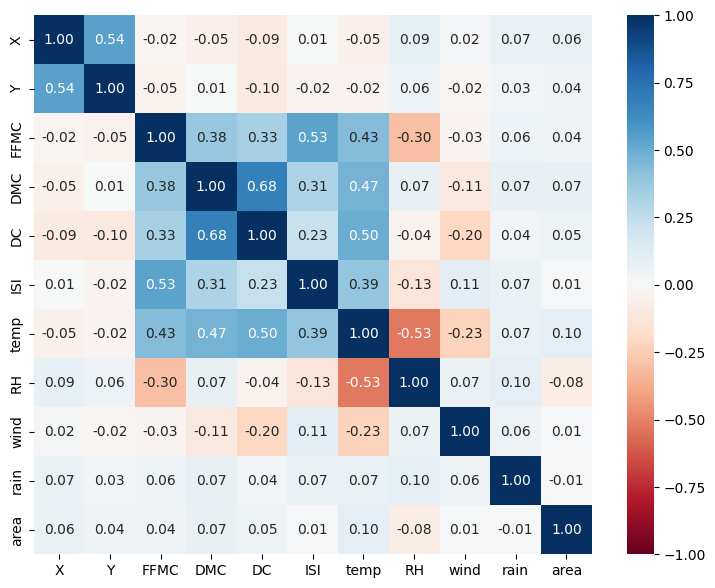

In [7]:
plt.figure(figsize=(9, 7))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', vmin=-1, vmax=1, center=0)
plt.show()

Nenhuma variável numérica isolada tem correlação forte com `area` — o maior valor absoluto já é bem fraco. Isso é mais um indício de que este não é um problema fácil para um modelo linear simples.

## Preparação dos dados

### Codificando as variáveis categóricas

In [8]:
print('Categorias em month:', sorted(df['month'].unique()))
print('Categorias em day:  ', sorted(df['day'].unique()))

Categorias em month: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']
Categorias em day:   ['fri', 'mon', 'sat', 'sun', 'thu', 'tue', 'wed']


Não há categorias duplicadas nem inconsistências de grafia (diferente do que vimos com `make` na aula de variáveis categóricas) — podemos codificar direto.

In [9]:
cat_cols = ['month', 'day']

# drop='first' evita a armadilha da variável dummy
encoder = OneHotEncoder(drop='first')
dummy_array = encoder.fit_transform(df[cat_cols])
dummy_df = pd.DataFrame(
    dummy_array.toarray(),
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

df_modelo = pd.concat([df.drop(columns=cat_cols), dummy_df], axis=1)

df_modelo.shape

(517, 28)

### Separando X, y e o conjunto de treino/teste

In [10]:
X = df_modelo.drop(columns=['area'])
y = df_modelo['area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelo de Regressão Linear

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)

print(f"R² treino: {r2_train:.4f}")
print(f"R² teste : {r2_test:.4f}")

R² treino: 0.0498
R² teste : 0.0148


Os dois valores de $R^2$ são baixos — o modelo explica pouquíssimo da variação da área queimada. Isso **não é um erro de código**: é o resultado esperado para um problema conhecido por ser difícil de modelar linearmente (a própria fonte do dataset descreve esta como uma tarefa de regressão difícil). O fato de treino e teste estarem próximos mostra que o modelo generaliza tão mal quanto se ajusta — não há overfitting, só falta de sinal linear nos dados.

## Avaliação

In [12]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'MAE : {mae:.3f}')
print(f'MSE : {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE : 24.527
MSE : 11613.675
RMSE: 107.767


### E o MAPE?

In [13]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAPE: {mape:.3%}')

MAPE: 2464253317894347264.000%


O MAPE explode para um valor absurdo (bem acima de 100%). Isso não é um bug: `y_test` tem vários registros com `area == 0`, e o MAPE divide o erro pelo valor real — dividir por (quase) zero gera uma porcentagem gigantesca, mesmo quando o erro absoluto é pequeno. **Lição:** o MAPE não é uma métrica adequada quando o alvo pode ser zero. Para este problema, MAE e RMSE são as métricas confiáveis.

### Real vs Previsto

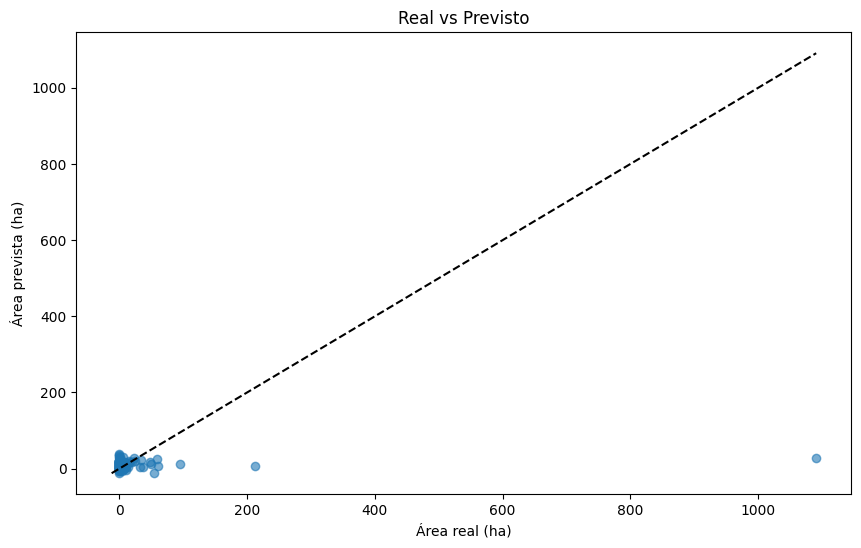

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='k')

plt.xlabel('Área real (ha)')
plt.ylabel('Área prevista (ha)')
plt.title('Real vs Previsto')
plt.show()

O gráfico deixa o problema visível: o modelo prevê valores próximos de zero para quase tudo, e não acompanha os poucos incêndios grandes (a linha pontilhada seria o previsto perfeito).

### Resíduos

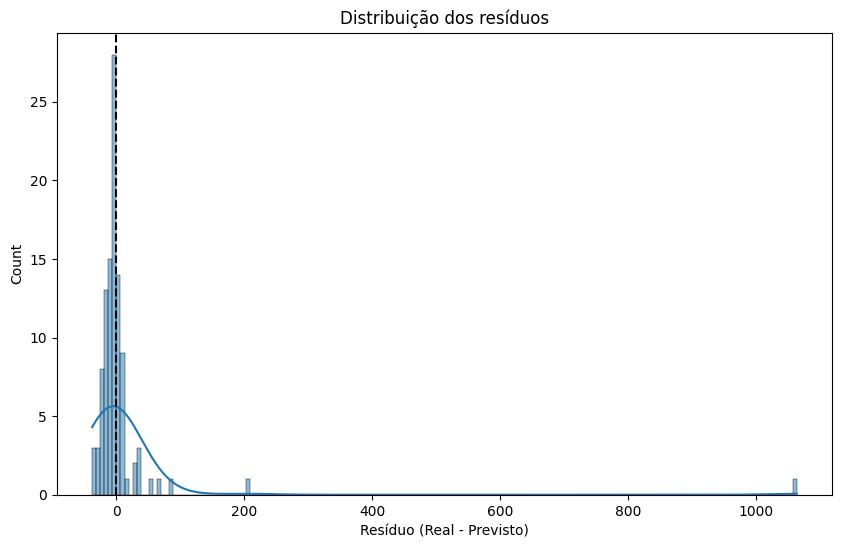

In [15]:
residuos = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Resíduo (Real - Previsto)')
plt.title('Distribuição dos resíduos')
plt.show()

## Conclusão

* O modelo linear simples captura muito pouco da variação da área queimada — $R^2$ de treino e teste ambos próximos de zero.
* Isso é esperado dado o formato da variável-alvo (extremamente assimétrica, quase metade dos valores iguais a zero) e a ausência de correlações fortes entre os preditores disponíveis e `area`.
* O MAPE se mostrou uma métrica inadequada aqui por causa dos zeros no alvo — MAE e RMSE são mais confiáveis neste caso.

### Possíveis caminhos além do escopo do curso

* Transformar `area` com `log(1 + area)` antes de treinar (sugerido pelos próprios autores do dataset), o que costuma ajudar bastante com alvos tão assimétricos.
* Modelos não-lineares (árvores, ensembles), que lidam melhor com relações que a regressão linear não consegue capturar.

Nenhuma dessas extensões é necessária para cumprir a missão do Lab — servem apenas como próximos passos para quem quiser ir além.